# Min-range estimation from beam altitude

This notebook calculates the minimum surface range at which the **highest non-birdbath elevation
sweep** first exceeds a chosen altitude threshold.  The logic is:

- At short ranges even the steepest beam is still below the threshold — the radar column is
  contained within the altitude window of interest.
- At the crossover range the steepest beam first climbs *above* the threshold — beyond this
  point the top of the column overshoots.

The crossover range is therefore a physically motivated lower bound for MESH retrieval:
gates inside it have an incomplete vertical column.

Birdbath sweeps (near-vertical, typically 90°) are excluded automatically; adjust
`birdbath_threshold` if needed.

**Workflow**
1. Set the parameters in the *Configuration* cell below.
2. Run all cells.
3. Read the printed recommendation and inspect the plot.
4. Copy the suggested `min_range` value into your retrieval code.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pyodim
from pyhail.mesh_ppi import _antenna_to_arc

In [11]:
# ── User parameters — adjust these ────────────────────────────────────────────
filename             = 'data/66_20231110_063000.pvol.h5'
altitude_threshold   = 15_000   # m ASL — beam above this is considered too high
birdbath_threshold   = 85       # deg  — sweeps at or above this angle are excluded
# ──────────────────────────────────────────────────────────────────────────────

In [12]:
# Load the radar volume
datasets  = pyodim.read_odim(filename, lazy_load=False)
radar_alt = datasets[0].attrs['height']   # m ASL

# Collect elevation angles and range arrays
elevations = [datasets[i]['elevation'].data[0] for i in range(len(datasets))]
ranges     = [datasets[i]['range'].values       for i in range(len(datasets))]

# Sort ascending by elevation, then drop birdbath sweeps
sort_idx          = np.argsort(elevations)
elevations_sorted = [elevations[i] for i in sort_idx]
ranges_sorted     = [ranges[i]     for i in sort_idx]

birdbath_mask     = [elev < birdbath_threshold for elev in elevations_sorted]
elevations_sorted = [e for e, keep in zip(elevations_sorted, birdbath_mask) if keep]
ranges_sorted     = [r for r, keep in zip(ranges_sorted,     birdbath_mask) if keep]

n_removed = birdbath_mask.count(False)
if n_removed:
    print(f"Removed {n_removed} birdbath sweep(s) with elevation ≥ {birdbath_threshold}°")

# Compute surface range (s) and altitude ASL (z) for every remaining sweep
s_dataset, z_dataset = [], []
for elev, rng in zip(elevations_sorted, ranges_sorted):
    s, z_arl = _antenna_to_arc(rng, elev)
    s_dataset.append(s)
    z_dataset.append(z_arl + radar_alt)   # convert ARL → ASL

Removed 1 birdbath sweep(s) with elevation ≥ 85°


In [13]:
# Find the crossover range on the highest (non-birdbath) elevation sweep
highest_z = z_dataset[-1]
highest_s = s_dataset[-1]

exceeds = highest_z > altitude_threshold

if np.any(exceeds):
    first_idx    = int(np.argmax(exceeds))
    min_range_m  = float(highest_s[first_idx])
    min_range_km = min_range_m / 1000
    print(f"Highest elevation sweep : {elevations_sorted[-1]:.2f}°")
    print(f"Altitude threshold      : {altitude_threshold/1000:.1f} km ASL")
    print(f"Radar altitude          : {radar_alt:.0f} m ASL")
    print()
    print(f"━━━ Recommended min_range ━━━━━━━━━━━━━━━━━━━━━")
    print(f"  {min_range_km:.2f} km  ({min_range_m:.0f} m)")
    print(f"  → pass  min_range={min_range_km:.1f}  to mesh_ppi.main()")
else:
    min_range_km = None
    print(f"The highest elevation beam ({elevations_sorted[-1]:.2f}°) never exceeds "
          f"{altitude_threshold/1000:.1f} km ASL within this scan's range.")
    print("No minimum range restriction is needed for this altitude threshold.")

Highest elevation sweep : 32.00°
Altitude threshold      : 15.0 km ASL
Radar altitude          : 175 m ASL

━━━ Recommended min_range ━━━━━━━━━━━━━━━━━━━━━
  23.81 km  (23810 m)
  → pass  min_range=23.8  to mesh_ppi.main()


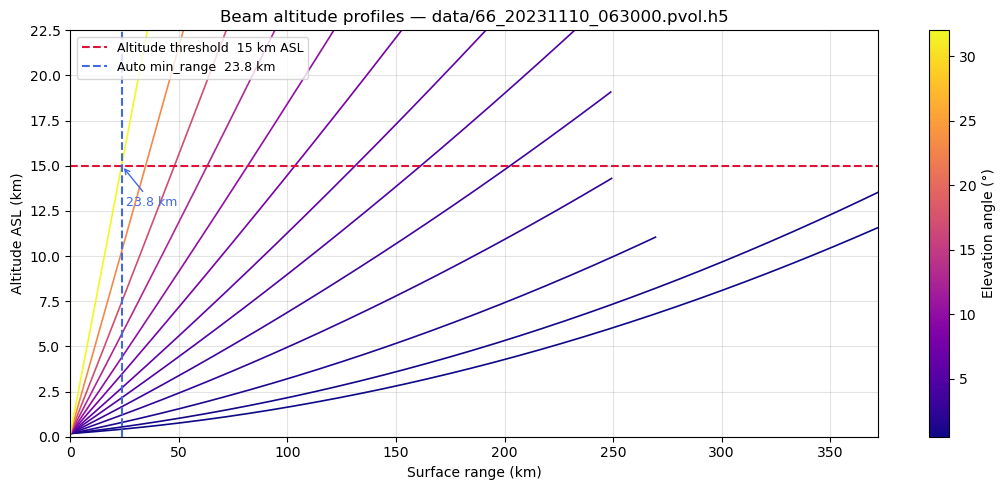

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=elevations_sorted[0], vmax=elevations_sorted[-1])

for s, z, elev in zip(s_dataset, z_dataset, elevations_sorted):
    ax.plot(s / 1000, z / 1000, color=cmap(norm(elev)), lw=1.2)

# Altitude threshold
ax.axhline(
    altitude_threshold / 1000, color='crimson', ls='--', lw=1.5,
    label=f'Altitude threshold  {altitude_threshold/1000:.0f} km ASL',
)

# Computed min_range
if min_range_km is not None:
    ax.axvline(
        min_range_km, color='royalblue', ls='--', lw=1.5,
        label=f'Auto min_range  {min_range_km:.1f} km',
    )
    ax.annotate(
        f'{min_range_km:.1f} km',
        xy=(min_range_km, altitude_threshold / 1000),
        xytext=(min_range_km + 2, altitude_threshold / 1000 * 0.85),
        color='royalblue', fontsize=9,
        arrowprops=dict(arrowstyle='->', color='royalblue', lw=1),
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Elevation angle (°)')

max_s_km = max(s.max() for s in s_dataset) / 1000

ax.set_xlim(0, max_s_km)
ax.set_ylim(0, altitude_threshold / 1000 * 1.5)
ax.set_xlabel('Surface range (km)')
ax.set_ylabel('Altitude ASL (km)')
ax.set_title(f'Beam altitude profiles — {filename}')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()